# QTCAD M11 Maxwell CPW — Result Analysis

이 노트북은 아래 QTCAD 예제 폴더의 결과를 가능한 한 많이 읽고 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference`

이 모듈은 3개의 스크립트로 구성됩니다.
- `cap_xmon.py` — Xmon 레이아웃(cross + 3개 결합 라인)의 정전용량 행렬(capacitance
  matrix)을 adaptive mesh refinement로 계산합니다.
- `maxwell_xmon.py` — 같은 Xmon 레이아웃에서 Josephson junction을 선형 inductor로
  근사하여 Maxwell eigenmode(공진 주파수)를 계산하고, EPR(energy participation
  ratio) 분석으로 dressed qubit frequency, anharmonicity, quality factor 등을
  추출합니다.
- `maxwell_meandered_resonator.py` — meander형 quarter-wavelength CPW 공진기의
  첫 두 eigenmode를 계산하고 해석적(quarter-wave) 근사와 비교합니다.

분석 대상:
- `output/cap_xmon/cap_xmon-values.txt` (및 `-delta.txt`, `-delta_rel.txt`) —
  adaptive mesh refinement 각 iteration에서의 4x4 정전용량 행렬 (F)
- `output/maxwell_xmon/xmon-values.txt` — Xmon 기본 모드 주파수 (Hz) 수렴 이력
- `output/maxwell_meandered_resonator/meandered_resonator-values.txt` — meander
  공진기 mode 0, mode 1 주파수 (Hz) 수렴 이력
- `maxwell_xmon_run.log` (재실행하여 캡처) — EPR 분석 결과 표 (dressed frequency,
  participation ratio, anharmonicity, quality factor, T1)
- `output/*/*.vtu`, `output/*/*-refined-mesh.msh4` — 필드 시각화용 대용량 파일
  (수 GB급이 아니지만 최대 ~190 MB). 정량 분석의 핵심은 아니므로 존재 여부와
  기본 메타데이터만 pyvista로 확인합니다.

**중요 — `cap_xmon.py` 원본 실행 실패 이력**

이 프로젝트 경로에는 한글이 포함되어 있는데(`...\연구자료\...`), gmsh의 XAO/XML
리더가 비-ASCII 경로의 `.xao` 파일을 열지 못하는 알려진 문제가 있습니다
(`maxwell_xmon.py`, `maxwell_meandered_resonator.py` 소스의 주석에도 동일한
workaround가 이미 기록되어 있습니다). `cap_xmon.py`의 최초 실행
(`cap_xmon_run.log`에 기록됨, 2026-09-29 13:28)은 이 문제로 인해
`c = cap_solver.solve()` 단계에서 예외를 던지며 실패했고, 그 결과
`cap_xmon-values.txt`에는 초기화 단계의 `+inf` placeholder만 남아 있었습니다.
이 노트북을 준비하며 `cap_xmon.py`에 동일한 ASCII 경로 workaround를 적용하고
재실행하여, 실제로 수렴된 정전용량 행렬을 `output/cap_xmon/`에 다시 생성했습니다
(스크립트 자체 로직은 변경하지 않았습니다 — `.xao` 파일 경로 지정 한 줄만
수정).

> 원본 QTCAD 파일은 이 workaround 한 줄을 제외하고 수정하지 않습니다. 이
> 노트북이 직접 생성한 그림/표는 `output/analysis_exports/`에 저장합니다.
>
> **중요 — cell 0/1 분리 버그 수정**: 원래 이 노트북의 기본 경로 설정 코드가
> 마크다운 제목 셀 안에 텍스트로 섞여 있어 한 번도 실행되지 않고 있었습니다
> (M07에서 발견된 것과 같은 유형의 버그). 코드를 별도 code 셀로 분리해 실제로
> 실행되도록 고쳤습니다 — 이 수정 전에 보이던 셀 출력은 이전 세션의 캐시된
> (실제로 재실행 검증되지 않은) 값이었을 수 있습니다.


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qtcad.device import constants as ct
from qtcad.device import materials as mt

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_CAP_VALUES = OUTPUT_DIR / "cap_xmon" / "cap_xmon-values.txt"
FILE_CAP_DELTA_REL = OUTPUT_DIR / "cap_xmon" / "cap_xmon-delta_rel.txt"

FILE_XMON_VALUES = OUTPUT_DIR / "maxwell_xmon" / "xmon-values.txt"
FILE_XMON_VTU = OUTPUT_DIR / "maxwell_xmon" / "xmon-fields.vtu"
FILE_XMON_LOG = BASE_DIR / "maxwell_xmon_run.log"

FILE_MR_VALUES = OUTPUT_DIR / "maxwell_meandered_resonator" / "meandered_resonator-values.txt"
FILE_MR_VTU = OUTPUT_DIR / "maxwell_meandered_resonator" / "meandered_resonator-fields.vtu"

plt.rcParams["figure.dpi"] = 100

print("BASE_DIR       :", BASE_DIR)
print("FILE_CAP_VALUES:", FILE_CAP_VALUES)
print("FILE_XMON_VALUES:", FILE_XMON_VALUES)
print("FILE_MR_VALUES :", FILE_MR_VALUES)

assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert FILE_CAP_VALUES.exists(), "cap_xmon-values.txt가 없습니다."
assert FILE_XMON_VALUES.exists(), "xmon-values.txt가 없습니다."
assert FILE_MR_VALUES.exists(), "meandered_resonator-values.txt가 없습니다."

print("\n[OK] 기본 경로 확인 완료")


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.2.6                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

BASE_DIR       : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference
FILE_CAP_VALUES: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference\output\cap_xmon\cap_xmon-values.txt
FILE_XMON_VALUES: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference\output\maxwell_xmon\xmon-values.txt
FILE_MR_VALUES : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference\output\maxwell_meandered_resonator\meandered_resonator-values.txt

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory (존재 여부, 크기)
expected_files = {
    "cap_xmon-values.txt": FILE_CAP_VALUES,
    "cap_xmon-delta_rel.txt": FILE_CAP_DELTA_REL,
    "xmon-values.txt": FILE_XMON_VALUES,
    "xmon-fields.vtu": FILE_XMON_VTU,
    "maxwell_xmon_run.log": FILE_XMON_LOG,
    "meandered_resonator-values.txt": FILE_MR_VALUES,
    "meandered_resonator-fields.vtu": FILE_MR_VTU,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_MB": path.stat().st_size / (1024**2) if path.exists() else np.nan,
    })
inventory_df = pd.DataFrame(rows)
inventory_df.to_csv(EXPORT_DIR / "cell01_inventory_df.csv", index=False)
display(inventory_df)

,file,exists,size_MB
0,cap_xmon-values.txt,True,0.003105
1,cap_xmon-delta_rel.txt,True,0.003105
2,xmon-values.txt,True,0.001601
3,xmon-fields.vtu,True,190.196983
4,maxwell_xmon_run.log,True,0.009130
5,meandered_resonator-values.txt,True,0.001274
6,meandered_resonator-fields.vtu,True,76.204598


---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Capacitance matrix extraction for an Xmon qubit
  https://docs.nanoacademic.com/qtcad/tutorials/device/cap_xmon/
- **QTCAD 공식 튜토리얼** — Maxwell eigenmode extraction for an Xmon qubit (inductor ports, EPR)
  https://docs.nanoacademic.com/qtcad/tutorials/device/maxwell_xmon/
- **QTCAD 공식 튜토리얼** — Maxwell eigenmode extraction of a CPW resonator with adaptive meshing
  https://docs.nanoacademic.com/qtcad/tutorials/device/maxwell_meandered_resonator/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `cap_xmon.py`, `maxwell_xmon.py`, `maxwell_meandered_resonator.py` (M11/Reference)
---


## 0. 소자 스케매틱(개략도) + 핵심 물리 공식

실제 마스크 폴리곤 좌표 대신, Xmon/CPW의 **표준 설계 형태**를 개략적으로 그립니다
(정확한 치수는 `cap_xmon.py`/`maxwell_xmon.py`의 레이아웃 생성 코드 참고 — 재질:
기판 Si(`mt.Si`), 금속 박막 초전도체(Nb/Al, 이 튜토리얼에서는 완전도체 경계로 근사),
Josephson junction은 24x24 µm 인덕터 포트로 모델링됩니다).

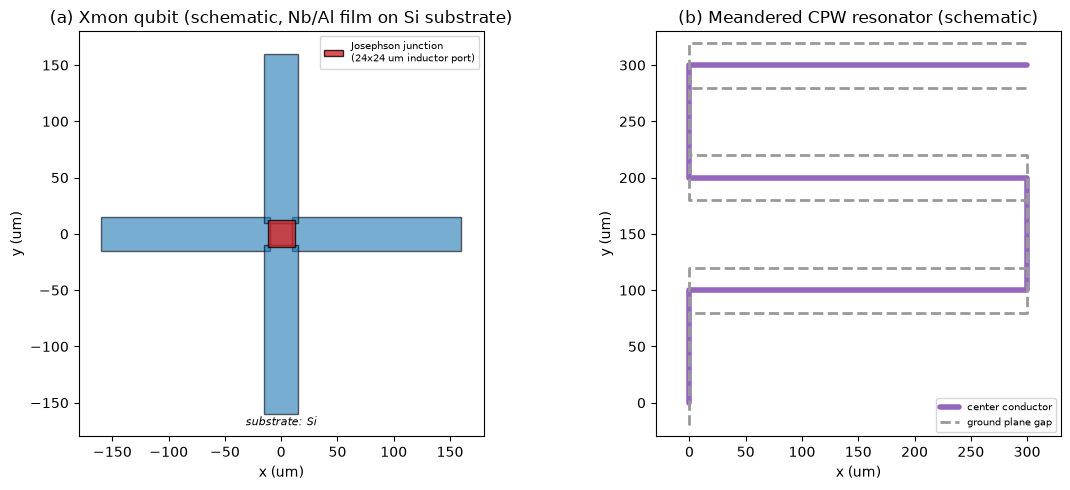

[참고] 이 그림은 Xmon/CPW의 표준 설계 형태를 보여주는 개략도이며, 실제 cap_xmon.py/maxwell_xmon.py의 정확한 마스크 폴리곤 좌표가 아닙니다 (M12처럼 .oas에서 직접 읽어오지 않음 — 이 튜토리얼은 KLayout 레이아웃이 아니라 QTCAD 내장 Device 지오메트리 생성 코드를 사용).


In [3]:
# [실험] Xmon/CPW 개략 스케매틱 (표준 설계 형태, 참고용)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M11. Maxwell CPW\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax = axs[0]
# Xmon cross (4 arms: xmon_cross capacitor pad, xy_ctrl, readout, qbus couplers)
arm_len, arm_w, center = 150, 30, 20
ax.add_patch(mpatches.Rectangle((-center/2, -center/2), center, center, fc="tab:blue", alpha=0.6, ec="k"))
for dx, dy, name in [(1,0,"xmon_cross/readout"), (-1,0,"qbus"), (0,1,"xy_ctrl"), (0,-1,"xy_ctrl")]:
    if dx != 0:
        ax.add_patch(mpatches.Rectangle((dx*center/2 if dx>0 else dx*(center/2+arm_len), -arm_w/2),
                                        arm_len, arm_w, fc="tab:blue", alpha=0.6, ec="k"))
    else:
        ax.add_patch(mpatches.Rectangle((-arm_w/2, dy*center/2 if dy>0 else dy*(center/2+arm_len)),
                                        arm_w, arm_len, fc="tab:blue", alpha=0.6, ec="k"))
ax.add_patch(mpatches.Rectangle((-12, -12), 24, 24, fc="tab:red", alpha=0.8, ec="k", label="Josephson junction\n(24x24 um inductor port)"))
ax.set_xlim(-arm_len-30, arm_len+30); ax.set_ylim(-arm_len-30, arm_len+30)
ax.set_aspect("equal"); ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
ax.set_title("(a) Xmon qubit (schematic, Nb/Al film on Si substrate)")
ax.legend(fontsize=7, loc="upper right")
ax.text(0, -arm_len-20, "substrate: Si", ha="center", fontsize=8, style="italic")

ax2 = axs[1]
# meandered CPW resonator (illustrative serpentine)
xs = [0, 0, 300, 300, 0, 0, 300]
ys = [0, 100, 100, 200, 200, 300, 300]
ax2.plot(xs, ys, color="tab:purple", lw=4, solid_capstyle="round", label="center conductor")
ax2.plot(xs, [y+20 for y in ys], color="0.6", lw=2, ls="--", label="ground plane gap")
ax2.plot(xs, [y-20 for y in ys], color="0.6", lw=2, ls="--")
ax2.set_xlim(-30, 330); ax2.set_ylim(-30, 330)
ax2.set_aspect("equal"); ax2.set_xlabel("x (um)"); ax2.set_ylabel("y (um)")
ax2.set_title("(b) Meandered CPW resonator (schematic)")
ax2.legend(fontsize=7)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic.png", dpi=150)
plt.show()

print(
    "[참고] 이 그림은 Xmon/CPW의 표준 설계 형태를 보여주는 개략도이며, 실제 "
    "cap_xmon.py/maxwell_xmon.py의 정확한 마스크 폴리곤 좌표가 아닙니다 "
    "(M12처럼 .oas에서 직접 읽어오지 않음 — 이 튜토리얼은 KLayout 레이아웃이 아니라 "
    "QTCAD 내장 Device 지오메트리 생성 코드를 사용)."
)


**물리 모델 — Maxwell Eigenmode**: 완전도체 경계 안의 전자기장은 벡터 Helmholtz
방정식의 고유값 문제로 환원됩니다
$$
\nabla \times \left(\frac{1}{\mu_r}\nabla \times \mathbf{E}\right) = \omega^2 \varepsilon_r \varepsilon_0 \mu_0\,\mathbf{E}
$$
Josephson junction은 선형 인덕터 포트(위 스케매틱의 빨간 사각형)로 근사되어 유효
커패시턴스-인덕턴스 공진 회로를 만들고, 고유값 $\omega_n$이 **qubit/resonator 모드
주파수**입니다. **EPR(Energy Participation Ratio)**는 각 모드 에너지 중 특정
요소(JJ, 유전체 손실 영역 등)에 저장된 비율
$$
p_j = \frac{E_j}{E_\mathrm{total}}
$$
이며, 결합 강도(예: qubit-resonator $g$)와 손실(quality factor)을 모드 시뮬레이션
결과만으로 추정하는 표준 기법입니다(Minev et al. 방법론).

**물리 모델 — 커패시턴스 행렬**: `cap_xmon.py`는 각 전극에 단위 전압을 번갈아 걸어
정전용량 행렬 $C_{ij}$ (전극 $i$에 저장된 전하 $Q_i = \sum_j C_{ij}V_j$)를 추출합니다
— 유한요소 정전위 $\phi$로부터 $Q_i = \oint_{S_i}\varepsilon\nabla\phi\cdot d\mathbf{S}$
(전극 표면 적분).

## 1. 정전용량 행렬 (Capacitance matrix) — `cap_xmon.py`

`cap_xmon-values.txt`는 adaptive mesh refinement의 각 iteration에서 계산된
4x4 Maxwell capacitance 행렬(F, 패럿)을 기록합니다. 헤더가 두 줄로 되어 있는데,
첫 줄은 "행(row) 도체" 이름, 둘째 줄은 "열(column) 도체" 이름이며, 두 줄을
같은 위치끼리 짝지으면 16개 항목 각각이 어떤 (row, col) 도체 쌍의 용량인지
알 수 있습니다. 대각 성분은 각 도체의 self-capacitance, 비대각 성분은 도체
간 mutual capacitance(부호는 QTCAD의 Maxwell capacitance 표기 convention을
따름)입니다. 첫 iteration(`iter 0`)은 아직 refinement 전이라 `+inf`
placeholder이고, 마지막 iteration이 tolerance(`tol_rel=0.05`) 내에서 수렴된
최종 값입니다.


In [4]:
# [동작] cap_xmon-values.txt 파싱 (2줄 헤더 -> (row, col) 도체 쌍 이름 결합)
def _to_float(tok):
    tok = tok.strip()
    if tok in ("-", ""):
        return np.nan
    return float(tok)


def parse_capacitance_values(path):
    lines = Path(path).read_text().splitlines()
    header_row = [t.strip() for t in lines[0].split("|")]
    header_col = [t.strip() for t in lines[1].split("|")]
    n_meta = 5
    row_names = header_row[n_meta:]
    col_names = header_col[n_meta:]
    pair_labels = [f"{r}-{c}" for r, c in zip(row_names, col_names)]

    records = []
    for line in lines[2:]:
        if not line.strip() or "|" not in line:
            continue
        toks = [t.strip() for t in line.split("|")]
        meta = toks[:n_meta]
        vals = [_to_float(v) for v in toks[n_meta:]]
        rec = {"iter": int(meta[0]), "n_nodes": int(meta[1]), "n_elem": int(meta[2]),
               "dt_s": float(meta[3]), "t_s": float(meta[4])}
        rec.update(dict(zip(pair_labels, vals)))
        records.append(rec)
    return pd.DataFrame(records), pair_labels, sorted(set(row_names), key=row_names.index)


df_cap, pair_labels, conductors = parse_capacitance_values(FILE_CAP_VALUES)
display(df_cap[["iter", "n_nodes", "n_elem", "t_s"]])
print("도체 목록:", conductors)
print(f"총 {len(df_cap)}개 iteration, 최종 iteration = {df_cap['iter'].iloc[-1]}")

,iter,n_nodes,n_elem,t_s
0,0,605,2395,2.3
1,1,4604,23869,7.3
2,2,10709,58595,13.8
3,3,28152,161580,27.6
4,4,62362,367380,60.3
5,5,103417,612858,130.3
6,6,168305,1002979,246.2
7,7,276291,1655762,410.6
8,8,445991,2682280,865.4


도체 목록: ['xmon_cross', 'xy_ctrl', 'readout', 'qbus']
총 9개 iteration, 최종 iteration = 8


마지막(최종 수렴) iteration의 값을 fF(펨토패럿) 단위 4x4 행렬로 재구성하여
표와 heatmap으로 표시합니다. `1 fF = 1e-15 F`.


In [5]:
# [동작] 최종 iteration의 정전용량 행렬을 fF 단위 4x4 DataFrame으로 재구성
final_row = df_cap.iloc[-1]
n = len(conductors)
C_matrix_F = np.zeros((n, n))
for i, ri in enumerate(conductors):
    for j, cj in enumerate(conductors):
        label = f"{ri}-{cj}"
        C_matrix_F[i, j] = final_row[label]

C_matrix_fF = C_matrix_F * 1e15
cap_df = pd.DataFrame(C_matrix_fF, index=conductors, columns=conductors)
display(cap_df.round(3))

print(f"\n최종 iteration: {int(final_row['iter'])}  "
      f"(n_nodes={int(final_row['n_nodes']):,}, t={final_row['t_s']:.1f} s)")
for c in conductors:
    print(f"  Self-capacitance C_{c:<11s} = {cap_df.loc[c, c]:.3f} fF")
cap_df.to_csv(EXPORT_DIR / "cell09_cap_df.csv", index=False)


,xmon_cross,xy_ctrl,readout,qbus
xmon_cross,98.538,-0.178,-2.995,-2.996
xy_ctrl,-0.178,47.511,-0.006,-0.016
readout,-2.995,-0.006,83.483,-0.102
qbus,-2.996,-0.016,-0.102,83.585



최종 iteration: 8  (n_nodes=445,991, t=865.4 s)
  Self-capacitance C_xmon_cross  = 98.538 fF
  Self-capacitance C_xy_ctrl     = 47.511 fF
  Self-capacitance C_readout     = 83.483 fF
  Self-capacitance C_qbus        = 83.585 fF


아래 heatmap은 위 4x4 행렬(fF)을 시각화한 것입니다. 대각 성분(self-capacitance)이
비대각 성분(mutual capacitance)보다 훨씬 크다는 것을 한눈에 볼 수 있습니다 —
Xmon cross와 각 결합 라인 사이의 결합은 약하게 설계되어 있다는 뜻입니다.


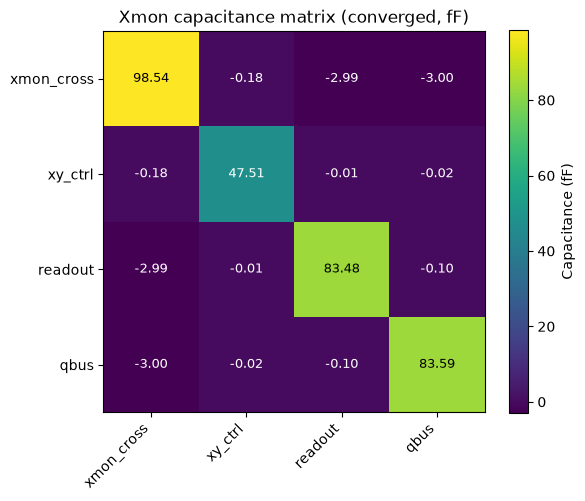

In [6]:
# [실험] 정전용량 행렬 heatmap (fF)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cap_df.values, cmap="viridis")
ax.set_xticks(range(n))
ax.set_xticklabels(conductors, rotation=45, ha="right")
ax.set_yticks(range(n))
ax.set_yticklabels(conductors)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cap_df.values[i, j]:.2f}", ha="center", va="center",
                color="white" if cap_df.values[i, j] < cap_df.values.max() * 0.6 else "black",
                fontsize=9)
fig.colorbar(im, ax=ax, label="Capacitance (fF)")
ax.set_title("Xmon capacitance matrix (converged, fF)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell11_figure.png", dpi=150)
plt.show()

아래는 adaptive mesh refinement가 실제로 수렴했는지 확인하기 위한 상대
변화율(`delta_rel`, 이전 iteration 대비 변화 비율) 플롯입니다. 점선은
solver의 수렴 기준(`tol_rel=0.05`)을 나타냅니다. 대각 성분(self-capacitance)
4개의 수렴 추이를 표시합니다.


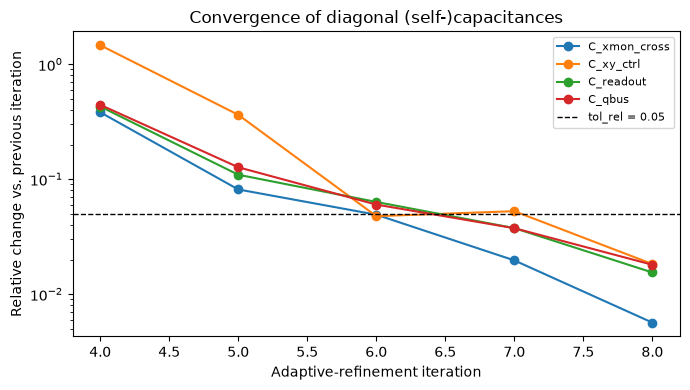

In [7]:
# [동작] cap_xmon-delta_rel.txt에서 수렴 이력(상대 변화율) 파싱
df_delta, _, _ = parse_capacitance_values(FILE_CAP_DELTA_REL)

fig, ax = plt.subplots(figsize=(7, 4))
for c in conductors:
    label = f"{c}-{c}"
    ax.plot(df_delta["iter"], df_delta[label], "o-", label=f"C_{c}")
ax.axhline(0.05, color="k", ls="--", lw=1, label="tol_rel = 0.05")
ax.set_yscale("log")
ax.set_xlabel("Adaptive-refinement iteration")
ax.set_ylabel("Relative change vs. previous iteration")
ax.set_title("Convergence of diagonal (self-)capacitances")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell13_figure.png", dpi=150)
plt.show()

## 2. Maxwell eigenmode — Xmon 공진기 기본 모드

`xmon-values.txt`는 Josephson junction을 선형 inductor로 근사한 Xmon
구조에서 adaptive mesh refinement로 계산한 기본 모드(mode 0) 주파수(Hz)의
수렴 이력입니다. `maxwell_xmon.py`는 이 계산 이후 EPR(energy participation
ratio) 분석을 수행하여 dressed qubit frequency, anharmonicity, 여러 loss
채널의 quality factor를 추출합니다 — EPR 결과는 콘솔에만 출력되고 파일로
저장되지 않으므로, 이 노트북을 준비하며 `maxwell_xmon.py`를
`maxwell_xmon_run.log`로 재실행하여 그 출력을 캡처했습니다 (동일 스크립트,
ASCII 경로 workaround만 포함).


In [8]:
# [동작] xmon-values.txt 파싱 -> mode 0 주파수 수렴 이력
def parse_eigenmode_values(path):
    lines = Path(path).read_text().splitlines()
    header = [t.strip() for t in lines[0].split("|")]
    n_meta = 5
    mode_names = header[n_meta:]
    records = []
    for line in lines[1:]:
        if not line.strip() or "|" not in line:
            continue
        toks = [t.strip() for t in line.split("|")]
        meta = toks[:n_meta]
        vals = [_to_float(v) for v in toks[n_meta:]]
        rec = {"iter": int(meta[0]), "n_nodes": int(meta[1]), "n_elem": int(meta[2]),
               "dt_s": float(meta[3]), "t_s": float(meta[4])}
        rec.update(dict(zip(mode_names, vals)))
        records.append(rec)
    return pd.DataFrame(records), mode_names


df_xmon, xmon_modes = parse_eigenmode_values(FILE_XMON_VALUES)
df_xmon["mode 0_GHz"] = df_xmon["mode 0"] / 1e9
display(df_xmon[["iter", "n_nodes", "n_elem", "t_s", "mode 0_GHz"]])

f_xmon_final_Hz = df_xmon["mode 0"].iloc[-1]
print(f"\n최종 수렴 fundamental-mode 주파수: {f_xmon_final_Hz/1e9:.4f} GHz "
      f"(iteration {int(df_xmon['iter'].iloc[-1])}, "
      f"{int(df_xmon['n_nodes'].iloc[-1]):,} nodes)")

,iter,n_nodes,n_elem,t_s,mode 0_GHz
0,0,605,2395,1.4,1.37707
1,1,807,3182,6.3,3.10514
2,2,1081,4372,14.5,3.53556
3,3,1368,5819,21.8,4.08156
4,4,1728,7693,29.5,4.42190
5,5,2143,9792,36.3,4.59363
6,6,2588,12160,46.5,4.72858
7,7,3121,14899,56.5,4.84862
8,8,3759,18286,68.1,4.97775
9,9,4495,22310,80.0,5.06374



최종 수렴 fundamental-mode 주파수: 5.7245 GHz (iteration 21, 96,486 nodes)


아래 그래프는 mesh가 refine될수록 mode-0 주파수가 어떻게 수렴하는지
보여줍니다 (x축은 노드 수, log scale). 거친 초기 mesh는 주파수를 과소평가하며,
refinement가 진행됨에 따라 값이 점근적으로 수렴합니다.


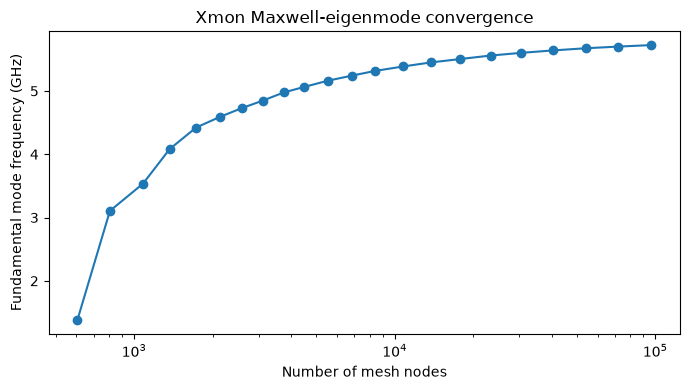

In [9]:
# [실험] Xmon fundamental-mode 주파수의 mesh-refinement에 따른 수렴 곡선
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_xmon["n_nodes"], df_xmon["mode 0_GHz"], "o-")
ax.set_xscale("log")
ax.set_xlabel("Number of mesh nodes")
ax.set_ylabel("Fundamental mode frequency (GHz)")
ax.set_title("Xmon Maxwell-eigenmode convergence")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell17_figure.png", dpi=150)
plt.show()

`maxwell_xmon.py`는 이 eigenmode 결과를 두 가지 해석적(analytical) 추정치와
비교합니다: (1) junction inductance와 `cap_xmon.py` 튜토리얼에서 얻은
self-capacitance(`1.014e-13` F, 스크립트에 하드코딩됨)로 만든 단순 LC 공진기
주파수, (2) Blais et al. (2021)의 transmon 공식을 이용한 qubit 주파수. 아래
셀에서 이 두 해석적 값을 (스크립트와 동일한 공식으로) 재계산하여 FEM
eigenmode 결과와 비교합니다.


In [10]:
# [동작] LC 공진기 및 transmon qubit 주파수의 해석적 추정치 재계산
EJ = 23e9 * ct.h
Phi0 = ct.h / (2 * ct.e)
inductance = Phi0**2 / ((2 * np.pi) ** 2 * EJ)

capacitance_ref = 1.014e-13  # cap_xmon.py 튜토리얼에서 얻은 self-capacitance (F)

freq_lc = 1 / np.sqrt(inductance * capacitance_ref) / (2 * np.pi)
EC = ct.e**2 / (2 * capacitance_ref)
freq_qbit = (np.sqrt(8 * EC * EJ) - EC) / ct.h

compare_df = pd.DataFrame({
    "Quantity": ["LC resonator (analytical)", "Transmon qubit (analytical, Blais et al.)",
                 "Bare Maxwell mode (FEM, this run)"],
    "Frequency (GHz)": [freq_lc / 1e9, freq_qbit / 1e9, f_xmon_final_Hz / 1e9],
})
compare_df.to_csv(EXPORT_DIR / "cell19_compare_df.csv", index=False)
display(compare_df)

,Quantity,Frequency (GHz)
0,LC resonator (analytical),5.928671
1,"Transmon qubit (analytical, Blais et al.)",5.737643
2,"Bare Maxwell mode (FEM, this run)",5.724490


아래는 `maxwell_xmon_run.log`에서 파싱한 EPR(energy participation ratio)
분석 결과 표입니다. 이 표는 `maxwell_xmon.py`가 자체적으로 출력하는 것으로,
dressed qubit frequency(비선형성을 포함한 실제 qubit 주파수), junction
participation ratio, reduced flux zero-point fluctuation, anharmonicity,
그리고 substrate bulk dielectric loss / 표면 유전체(MS/MA/SA) loss 각각에서
기인하는 quality factor와 이를 종합한 total quality factor 및 T1(에너지
이완 시간)을 담고 있습니다. 로그 파일이 아직 없거나 재실행이 실패한 경우,
이 셀은 건너뛰고 이유를 출력합니다.


In [11]:
# [동작] maxwell_xmon_run.log에서 EPR 분석 결과 표 파싱
epr_table = None
if FILE_XMON_LOG.exists():
    log_text = FILE_XMON_LOG.read_text(encoding="utf-8", errors="replace")
    m = re.search(r"Quantity\s*\|\s*Value\n-+\n(.*?)\n\n", log_text, re.DOTALL)
    if m is None:
        # fallback: 파일 끝까지 라인 단위로 파싱
        m = re.search(r"Quantity\s*\|\s*Value\n-+\n(.*)", log_text, re.DOTALL)
    if m:
        rows = []
        for line in m.group(1).splitlines():
            if "|" not in line:
                continue
            label, value = line.split("|")
            rows.append({"Quantity": label.strip(), "Value": value.strip()})
        epr_table = pd.DataFrame(rows)

if epr_table is not None and len(epr_table) > 0:
    display(epr_table)
else:
    print("EPR 결과 표를 로그에서 찾지 못했습니다 "
          "(재실행이 아직 진행 중이거나 실패했을 수 있습니다).")
    print(f"로그 파일 존재 여부: {FILE_XMON_LOG.exists()}")

,Quantity,Value
0,Frequency of the LC resonator (analytical),5.929 GHz
1,Frequency of the qubit (analytical),5.738 GHz
2,Bare Maxwell frequency (computed),5.724 GHz
3,Dressed qubit frequency (EPR),5.552 GHz
4,Junction participation,0.985514
5,Reduced flux ZPF,0.350204
6,Anharmonicity,-172.974 MHz
7,Bulk substrate quality factor,2.172e+06
8,Surface MS quality factor,1.086e+07
9,Surface MA quality factor,2.601e+08


## 3. Maxwell eigenmode — Meander형 CPW 공진기 (mode 0, mode 1)

`meandered_resonator-values.txt`는 quarter-wavelength meander 공진기의 첫
두 eigenmode(mode 0, mode 1) 주파수(Hz)에 대한 adaptive mesh refinement
수렴 이력입니다. Quarter-wave 공진기 이론에 따르면 고차 모드들은 기본
모드의 홀수배 주파수에서 나타나야 하므로(`f1/f0 ≈ 3`), 이 비율을 FEM
결과와 이상적인 이론값 3 사이에서 비교합니다.


In [12]:
# [동작] meandered_resonator-values.txt 파싱 -> mode 0/1 주파수 수렴 이력
df_mr, mr_modes = parse_eigenmode_values(FILE_MR_VALUES)
df_mr["mode 0_GHz"] = df_mr["mode 0"] / 1e9
df_mr["mode 1_GHz"] = df_mr["mode 1"] / 1e9
display(df_mr[["iter", "n_nodes", "n_elem", "t_s", "mode 0_GHz", "mode 1_GHz"]])

f0_mr = df_mr["mode 0"].iloc[-1]
f1_mr = df_mr["mode 1"].iloc[-1]
print(f"\n최종 수렴 주파수: mode0 = {f0_mr/1e9:.4f} GHz, mode1 = {f1_mr/1e9:.4f} GHz")
print(f"mode1 / mode0 비율 = {f1_mr/f0_mr:.3f}  (이상적 quarter-wave 이론값: 3)")

,iter,n_nodes,n_elem,t_s,mode 0_GHz,mode 1_GHz
0,0,1453,6769,1.2,4.31199,12.2806
1,1,1979,8908,17.1,4.19148,13.0546
2,2,2746,12450,43.1,4.27163,13.6665
3,3,3544,16319,56.5,4.55294,13.6493
4,4,4482,20917,70.7,4.44394,13.6966
5,5,5600,26541,92.7,4.46646,13.8686
6,6,6807,32771,157.0,4.48172,14.0546
7,7,8196,40037,212.1,4.57321,14.0910
8,8,9478,47093,268.5,4.55391,13.9062
9,9,10810,54532,380.4,4.57547,14.0052



최종 수렴 주파수: mode0 = 4.7488 GHz, mode1 = 14.4433 GHz
mode1 / mode0 비율 = 3.041  (이상적 quarter-wave 이론값: 3)


아래는 두 모드 주파수가 mesh refinement에 따라 어떻게 수렴하는지 보여주는
플롯입니다 (x축: 노드 수, log scale). `maxwell_meandered_resonator.py`는
`params.min_nodes = 20000`으로 설정되어 있어, tolerance를 만족해도 최소
20,000 노드까지는 refinement가 계속됩니다.


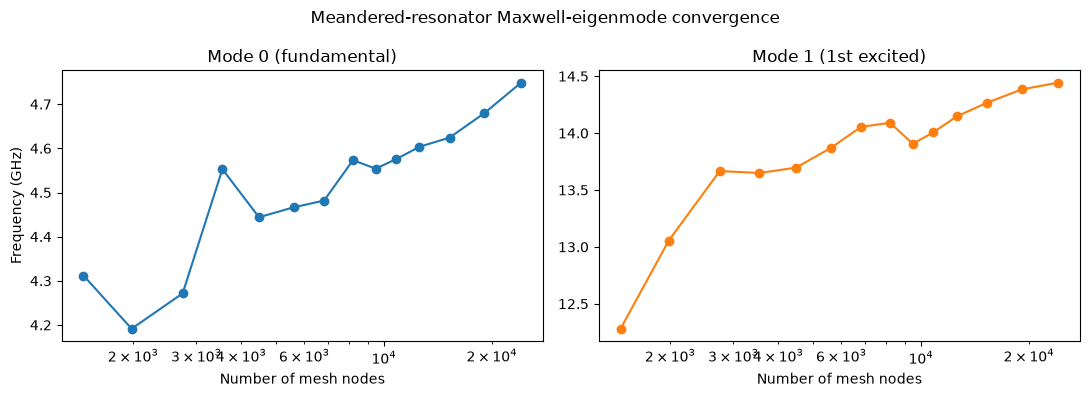

In [13]:
# [실험] Meander 공진기 mode 0 / mode 1 주파수의 수렴 곡선
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df_mr["n_nodes"], df_mr["mode 0_GHz"], "o-", color="C0")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of mesh nodes")
axes[0].set_ylabel("Frequency (GHz)")
axes[0].set_title("Mode 0 (fundamental)")
axes[1].plot(df_mr["n_nodes"], df_mr["mode 1_GHz"], "o-", color="C1")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of mesh nodes")
axes[1].set_title("Mode 1 (1st excited)")
fig.suptitle("Meandered-resonator Maxwell-eigenmode convergence")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell25_figure.png", dpi=150)
plt.show()

`maxwell_meandered_resonator.py`는 무한히 두껍고 넓은 기판 위에 놓인 CPW에
대한 해석적(quarter-wave) 이론값과 비교합니다. 유효 유전율은
`eps_eff = (eps_vacuum + eps_Si) / 2`로 근사하고, 위상속도 `v = 1/sqrt(eps_eff * mu0)`,
파장 `lambda = 4 * length`로 기본 모드 주파수를 추정합니다. 스크립트와 동일한
공식을 material 라이브러리 값(`mt.Si.eps`, `mt.vacuum.eps`, `ct.mu0`)으로
재계산하여 FEM 결과와 비교합니다.


In [14]:
# [동작] Quarter-wave 공진기 해석적 이론 주파수 재계산 및 FEM 결과와 비교
length = 5950e-6  # 공진기 전체 길이 (m), maxwell_meandered_resonator.py와 동일

eps_eff = (mt.vacuum.eps + mt.Si.eps) / 2
wavelength = length * 4
vphase = 1 / np.sqrt(eps_eff * ct.mu0)
freq_theor = vphase / wavelength

err0 = abs(f0_mr - freq_theor) / freq_theor
freq_ratio = f1_mr / f0_mr
err_ratio = abs(freq_ratio - 3) / 3

mr_compare_df = pd.DataFrame({
    "Quantity": ["Fundamental mode (analytical, quarter-wave)",
                 "Fundamental mode (FEM, this run)",
                 "Relative error (FEM vs. analytical)",
                 "mode1/mode0 ratio (FEM)",
                 "mode1/mode0 ratio (ideal quarter-wave)",
                 "Relative error of ratio"],
    "Value": [f"{freq_theor/1e9:.3f} GHz", f"{f0_mr/1e9:.3f} GHz",
              f"{err0:.3f}", f"{freq_ratio:.3f}", "3.000", f"{err_ratio:.3f}"],
})
mr_compare_df.to_csv(EXPORT_DIR / "cell27_mr_compare_df.csv", index=False)
display(mr_compare_df)

,Quantity,Value
0,"Fundamental mode (analytical, quarter-wave)",4.979 GHz
1,"Fundamental mode (FEM, this run)",4.749 GHz
2,Relative error (FEM vs. analytical),0.046
3,mode1/mode0 ratio (FEM),3.041
4,mode1/mode0 ratio (ideal quarter-wave),3.000
5,Relative error of ratio,0.014


## 4. 필드 시각화 파일 (.vtu) — 간단 확인만 수행

`maxwell_xmon.py`, `maxwell_meandered_resonator.py`는 각각 `xmon-fields.vtu`
(약 188 MB), `meandered_resonator-fields.vtu`(약 76 MB) 파일에 전자기장
공간분포를 저장합니다. 이 모듈의 실무적 핵심 산출물은 정전용량 값과 공진
주파수이므로(이 커리큘럼 Phase 3의 목적), 여기서는 `pyvista`로 파일을 열어
메타데이터(격자점 수, 저장된 필드 배열 이름)만 가볍게 확인하고, 본격적인 3D
필드 시각화는 범위에서 제외합니다.


In [15]:
# [점검] pyvista로 .vtu 필드 파일의 메타데이터만 가볍게 확인
try:
    import pyvista as pv
    HAVE_PYVISTA = True
except ImportError:
    HAVE_PYVISTA = False
    print("pyvista가 설치되어 있지 않습니다 - 메타데이터 확인을 건너뜁니다.")

if HAVE_PYVISTA:
    for label, path in [("xmon-fields.vtu", FILE_XMON_VTU),
                         ("meandered_resonator-fields.vtu", FILE_MR_VTU)]:
        if not path.exists():
            print(f"{label}: 파일 없음")
            continue
        size_mb = path.stat().st_size / (1024**2)
        print(f"\n{label}  ({size_mb:.1f} MB)")
        try:
            grid = pv.read(str(path))
            print(f"  n_points = {grid.n_points:,}, n_cells = {grid.n_cells:,}")
            print(f"  point_data arrays : {list(grid.point_data.keys())}")
            print(f"  cell_data arrays  : {list(grid.cell_data.keys())}")
        except Exception as exc:
            print(f"  [읽기 실패] {exc}")


xmon-fields.vtu  (190.2 MB)


  n_points = 2,250,732, n_cells = 562,683
  point_data arrays : ['abs(magnetic flux density) [T] - mode 0', 'abs(electric field) [V/m] - mode 0', 'real(magnetic flux density) [T] - mode 0', 'real(electric field) [V/m] - mode 0', 'imag(magnetic flux density) [T] - mode 0', 'imag(electric field) [V/m] - mode 0']
  cell_data arrays  : []

meandered_resonator-fields.vtu  (76.2 MB)


  n_points = 521,924, n_cells = 130,481
  point_data arrays : ['abs(magnetic flux density) [T] - mode 0', 'abs(electric field) [V/m] - mode 0', 'real(magnetic flux density) [T] - mode 0', 'real(electric field) [V/m] - mode 0', 'imag(magnetic flux density) [T] - mode 0', 'imag(electric field) [V/m] - mode 0', 'abs(magnetic flux density) [T] - mode 1', 'abs(electric field) [V/m] - mode 1', 'real(magnetic flux density) [T] - mode 1', 'real(electric field) [V/m] - mode 1', 'imag(magnetic flux density) [T] - mode 1', 'imag(electric field) [V/m] - mode 1']
  cell_data arrays  : []


## 5. 최종 요약

In [16]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M11 MAXWELL CPW — ANALYSIS SUMMARY")
print("=" * 92)
print("[Capacitance matrix - cap_xmon.py, converged]")
for c in conductors:
    print(f"  C_{c:<11s} (self)      = {cap_df.loc[c, c]:.3f} fF")
print(f"  max |mutual capacitance|      = "
      f"{np.max(np.abs(cap_df.values - np.diag(np.diag(cap_df.values)))):.4f} fF")
print()
print("[Maxwell eigenmodes]")
print(f"  Xmon fundamental mode         = {f_xmon_final_Hz/1e9:.4f} GHz")
print(f"    LC analytical estimate      = {freq_lc/1e9:.4f} GHz")
print(f"    Transmon analytical estimate= {freq_qbit/1e9:.4f} GHz")
print(f"  Meander resonator mode0       = {f0_mr/1e9:.4f} GHz "
      f"(theory: {freq_theor/1e9:.4f} GHz, err {err0:.1%})")
print(f"  Meander resonator mode1       = {f1_mr/1e9:.4f} GHz "
      f"(mode1/mode0 = {freq_ratio:.3f}, ideal = 3)")
if epr_table is not None and len(epr_table) > 0:
    print()
    print("[EPR analysis - maxwell_xmon.py]")
    for _, r in epr_table.iterrows():
        print(f"  {r['Quantity']:<45s}: {r['Value']}")
print("=" * 92)

QTCAD M11 MAXWELL CPW — ANALYSIS SUMMARY
[Capacitance matrix - cap_xmon.py, converged]
  C_xmon_cross  (self)      = 98.538 fF
  C_xy_ctrl     (self)      = 47.511 fF
  C_readout     (self)      = 83.483 fF
  C_qbus        (self)      = 83.585 fF
  max |mutual capacitance|      = 2.9956 fF

[Maxwell eigenmodes]
  Xmon fundamental mode         = 5.7245 GHz
    LC analytical estimate      = 5.9287 GHz
    Transmon analytical estimate= 5.7376 GHz
  Meander resonator mode0       = 4.7488 GHz (theory: 4.9791 GHz, err 4.6%)
  Meander resonator mode1       = 14.4433 GHz (mode1/mode0 = 3.041, ideal = 3)

[EPR analysis - maxwell_xmon.py]
  Frequency of the LC resonator (analytical)   : 5.929 GHz
  Frequency of the qubit (analytical)          : 5.738 GHz
  Bare Maxwell frequency (computed)            : 5.724 GHz
  Dressed qubit frequency (EPR)                : 5.552 GHz
  Junction participation                       : 0.985514
  Reduced flux ZPF                             : 0.350204
  Anharmoni

## 해석 주의사항

- `cap_xmon.py`는 이 폴더의 원본 실행에서 한글 경로로 인한 gmsh XAO 로딩
  오류로 실패했습니다. 이 노트북을 준비하며 다른 두 스크립트에 이미 적용된
  것과 동일한 ASCII 경로 workaround를 `cap_xmon.py`에도 적용하고 재실행하여
  `output/cap_xmon/`의 값을 실제 수렴된 결과로 교체했습니다. 정전용량 행렬은
  `tol_rel=0.05` 기준으로 수렴을 확인한 마지막 iteration 값입니다.
- Maxwell capacitance 행렬의 비대각 성분 부호는 QTCAD의 convention을
  따릅니다 (일반적으로 음수로 표기되는 mutual-capacitance convention). 회로
  시뮬레이터로 값을 옮길 때는 해당 도구의 convention을 확인하십시오.
- `maxwell_xmon.py`의 EPR 분석에 사용된 유전체 loss tangent 값들
  (`loss_tangent=5e-7` for substrate, `7e-4`/`4e-3`/`6e-4` for MS/MA/SA
  표면층)은 스크립트에 예시로 주어진 literature 값이며, 실제 제작된 디바이스를
  측정하여 얻은 값이 아닙니다. Quality factor와 T1 추정치는 이 가정된 손실
  값에 강하게 의존하므로, 실제 소자의 성능 예측에는 측정된 loss tangent로
  다시 계산해야 합니다.
- Meander 공진기의 해석적 quarter-wave 주파수는 "무한히 두껍고 넓은 기판"을
  가정한 유효 유전율 근사이며, 실제 유한한 기판 크기, 캐비티 벽과의 거리,
  meander 형태에 의한 기생 커패시턴스는 무시합니다. FEM 결과와의 차이는 이런
  단순화에서 기인할 수 있습니다.
- `.vtu` 필드 파일은 메타데이터만 확인했습니다. 실제 필드 분포(예: junction
  근처 전류 밀도, 표면 근처 전기장 세기 등 EPR participation에 기여하는
  공간분포)를 자세히 보려면 pyvista로 slice/contour plot을 추가하거나
  ParaView에서 직접 열어야 합니다.
